<a href="https://colab.research.google.com/github/aryaganu10-cpu/GenAi/blob/main/genai_task_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import os
from PIL import Image
import glob

# 1. Device Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Hyperparameters (Adapted for Floorplans)
HPARAMS = {
    "img_size": 256,         # Resolution suitable for floorplan details
    "inference_steps": 100,  # High steps for cleaner lines
    "batch_size": 32,
    "lr": 1e-4,
    "epochs": 50,            # 50 epochs is a good baseline
    "channels": 1,           # Grayscale is sufficient for floorplans
    "num_classes": 1         # Single class: "floorplan"
}

# 3. Data Extraction
# We unzip the floorplans into a specific directory 'floorplan_data'
# Note: Ensure the zip file path matches where you uploaded it in Colab
if os.path.exists('/content/floorplans_v2-20251223T170650Z-3-001.zip'):
    print("Found zip file. Extracting...")
    !unzip -q /content/floorplans_v2-20251223T170650Z-3-001.zip -d floorplan_data
    print("Dataset extracted to 'floorplan_data'.")
else:
    print("Warning: Zip file not found. Please ensure 'floorplans_v2-20251223T170650Z-3-001.zip' is uploaded.")

Using device: cuda
Found zip file. Extracting...
Dataset extracted to 'floorplan_data'.


In [ ]:
# --- Dataset Definition ---
class FloorplanDataset(torch.utils.data.Dataset):
    def __init__(self, root_dir, size=(256, 256), transform=None):
        self.root_dir = root_dir
        self.size = size
        self.transform = transform
        self.image_paths = []

        # Recursively find all images in the extracted folder
        for ext in ['jpg', 'jpeg', 'png']:
            self.image_paths.extend(glob.glob(os.path.join(root_dir, '**', f'*.{ext}'), recursive=True))

        if not self.image_paths:
            print(f"⚠️ Debug: Checked {root_dir} but found no images.")
        else:
            print(f"✅ Found {len(self.image_paths)} floorplan images.")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        try:
            img = Image.open(img_path).convert('L') # Force Grayscale
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a blank image in case of error to prevent crash
            img = Image.new('L', self.size)

        label = 0 # Single class for floorplans

        if self.transform:
            img = self.transform(img)
        return img, label

# --- Model Components (Standard Flow Matching Architecture) ---
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)
        if up:
            self.conv1 = nn.Conv2d(2*in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.bnorm1 = nn.BatchNorm2d(out_ch)
        self.bnorm2 = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU()

    def forward(self, x, t):
        h = self.bnorm1(self.relu(self.conv1(x)))
        time_emb = self.relu(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.bnorm2(self.relu(self.conv2(h)))
        return self.transform(h)

class ConditionalUNet(nn.Module):
    def __init__(self):
        super().__init__()
        img_channels = HPARAMS["channels"]
        down_channels = (32, 64, 128)
        up_channels = (128, 64, 32)
        out_dim = img_channels
        time_emb_dim = 32
        classes = HPARAMS["num_classes"]

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        self.class_emb = nn.Embedding(classes, time_emb_dim)
        self.conv0 = nn.Conv2d(img_channels, down_channels[0], 3, padding=1)
        self.downs = nn.ModuleList([Block(down_channels[i], down_channels[i+1], time_emb_dim) for i in range(len(down_channels)-1)])
        self.ups = nn.ModuleList([Block(up_channels[i], up_channels[i+1], time_emb_dim, up=True) for i in range(len(up_channels)-1)])
        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, t_float, class_label):
        t = self.time_mlp(t_float)
        c = self.class_emb(class_label)
        t = t + c
        x = self.conv0(x)
        residuals = []
        for down in self.downs:
            x = down(x, t)
            residuals.append(x)
        for up in self.ups:
            residual = residuals.pop()
            x = torch.cat((x, residual), dim=1)
            x = up(x, t)
        return self.output(x)

class FlowMatching:
    def __init__(self):
        pass

    def compute_loss(self, model, x_1, labels):
        b = x_1.shape[0]
        x_0 = torch.randn_like(x_1)
        t = torch.rand(b, device=x_1.device)
        t_view = t.view(b, 1, 1, 1)
        x_t = (1 - t_view) * x_0 + t_view * x_1
        v_target = x_1 - x_0
        v_pred = model(x_t, t, labels)
        return F.mse_loss(v_pred, v_target)

    @torch.no_grad()
    def sample(self, model, n_samples, class_label_idx, size, steps=50):
        model.eval()
        x = torch.randn((n_samples, 1, size, size)).to(device)
        labels = torch.full((n_samples,), class_label_idx, dtype=torch.long).to(device)
        dt = 1.0 / steps
        for i in range(steps):
            t_curr = torch.ones(n_samples).to(device) * (i / steps)
            v_pred = model(x, t_curr, labels)
            x = x + v_pred * dt
        model.train()
        return x

In [ ]:
def train_floorplan_model():
    # 1. Prepare Data
    dataset = FloorplanDataset(
        root_dir='floorplan_data', # The folder we extracted to in Chunk 1
        size=(HPARAMS["img_size"], HPARAMS["img_size"]),
        transform=transforms.Compose([
            transforms.Resize((HPARAMS["img_size"], HPARAMS["img_size"])),
            transforms.ToTensor(),
            # Normalization helps training stability
            transforms.Normalize([0.5], [0.5])
        ])
    )
    dataloader = DataLoader(dataset, batch_size=HPARAMS["batch_size"], shuffle=True)

    # 2. Initialize Model
    model = ConditionalUNet().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=HPARAMS["lr"])
    flow = FlowMatching()

    print(f"🏗️ Starting Flow Matching training for {HPARAMS['epochs']} epochs on Floorplans...")

    # 3. Training Loop
    for epoch in range(HPARAMS['epochs']):
        pbar = tqdm(dataloader)
        epoch_loss = 0
        for step, (images, labels) in enumerate(pbar):
            images = images.to(device)
            labels = labels.to(device)

            # Compute Flow Matching Loss
            loss = flow.compute_loss(model, images, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            pbar.set_description(f"Epoch {epoch} | Loss: {loss.item():.4f}")

    return model, flow

✅ Found 1000 floorplan images.
🏗️ Starting Flow Matching training for 50 epochs on Floorplans...


Epoch 0 | Loss: 1.3065: 100%|██████████| 32/32 [00:14<00:00,  2.23it/s]
Epoch 1 | Loss: 0.9326: 100%|██████████| 32/32 [00:12<00:00,  2.52it/s]
Epoch 2 | Loss: 0.8602: 100%|██████████| 32/32 [00:12<00:00,  2.51it/s]
Epoch 3 | Loss: 0.7404: 100%|██████████| 32/32 [00:12<00:00,  2.49it/s]
Epoch 4 | Loss: 0.8194: 100%|██████████| 32/32 [00:12<00:00,  2.49it/s]
Epoch 5 | Loss: 0.6378: 100%|██████████| 32/32 [00:12<00:00,  2.47it/s]
Epoch 6 | Loss: 0.5293: 100%|██████████| 32/32 [00:12<00:00,  2.46it/s]
Epoch 7 | Loss: 0.3653: 100%|██████████| 32/32 [00:13<00:00,  2.45it/s]
Epoch 8 | Loss: 0.4334: 100%|██████████| 32/32 [00:13<00:00,  2.43it/s]
Epoch 9 | Loss: 0.2593: 100%|██████████| 32/32 [00:13<00:00,  2.44it/s]
Epoch 10 | Loss: 0.2216: 100%|██████████| 32/32 [00:13<00:00,  2.44it/s]
Epoch 11 | Loss: 0.1659: 100%|██████████| 32/32 [00:13<00:00,  2.45it/s]
Epoch 12 | Loss: 0.1736: 100%|██████████| 32/32 [00:13<00:00,  2.45it/s]
Epoch 13 | Loss: 0.2568: 100%|██████████| 32/32 [00:13<00:00,

 Model saved to floorplan_flow_model.pth

 Generating Synthetic Floorplans...


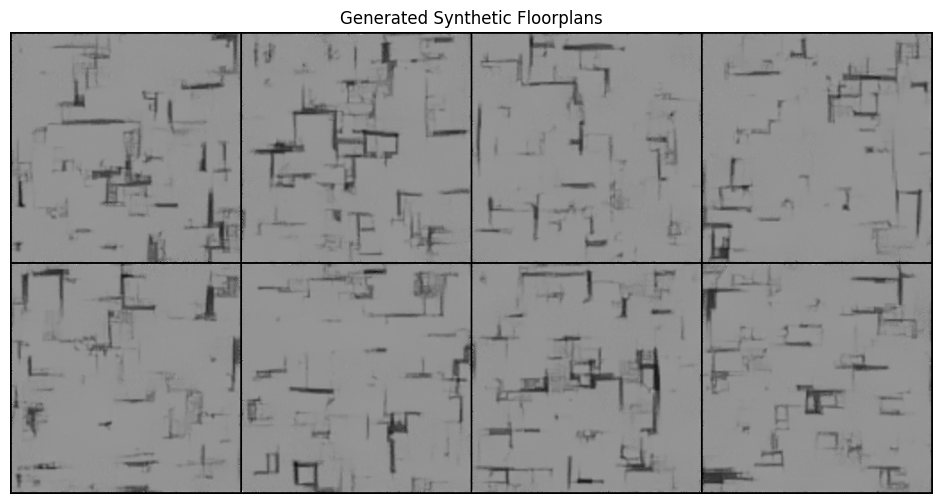

In [ ]:
def generate_floorplan_grid(model, flow, n_samples=8):
    print("\n Generating Synthetic Floorplans...")
    steps = HPARAMS["inference_steps"]

    # Generate samples
    generated_images = flow.sample(
        model,
        n_samples=n_samples,
        class_label_idx=0,
        size=HPARAMS["img_size"],
        steps=steps
    )

    # Denormalize for visualization (if we normalized in dataset)
    # generated_images = (generated_images * 0.5) + 0.5

    grid = make_grid(generated_images, nrow=4, padding=2, normalize=True)

    plt.figure(figsize=(12, 6))
    plt.imshow(grid.permute(1, 2, 0).cpu().numpy(), cmap='gray')
    plt.title(f"Generated Synthetic Floorplans")
    plt.axis('off')
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    # 1. Train
    trained_model, flow_manager = train_floorplan_model()

    # 2. Save
    torch.save(trained_model.state_dict(), "floorplan_flow_model.pth")
    print(" Model saved to floorplan_flow_model.pth")

    # 3. Generate
    generate_floorplan_grid(trained_model, flow_manager, n_samples=8)